# 🏁 机器学习马拉松：0-1 构建用户流失预测系统 (Churn Prediction)

> **本次马拉松目标**：
> 模拟真实业务场景，从一份 "脏数据" 开始，手动完成特征工程、模型训练、效果评估与业务策略产出的全流程。
>
> **核心技能点**：
> 1.  **特征工程 (Feature Engineering)**: 处理分类变量 (One-Hot)、数值归一化 (Scaler)、构造新特征。
> 2.  **模型训练 (Model Training)**: 使用 `LogisticRegression` 作为 Baseline，进阶使用 `XGBoost` 或 `RandomForest`。
> 3.  **模型评估 (Evaluation)**: 混淆矩阵、Precision/Recall、ROC-AUC。
> 4.  **模型解释 (Interpretability)**: 使用 `SHAP` 值向业务方解释 "为什么他会流失"。

---

## 1. 模拟数据生成 (Data Generation)
我们首先生成一份包含 "噪音" 和 "真实信号" 的模拟数据。
*   **User Profile**: 性别、年龄、城市
*   **Usage Behavior**: 活跃天数、最后一次登录时间、会员等级
*   **Label**: 是否流失 (Churn)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置随机种子
np.random.seed(42)

# 生成 5000 个用户
n_samples = 5000

data = {
    'user_id': [f'U{i:04d}' for i in range(n_samples)],
    'age': np.random.normal(30, 10, n_samples).astype(int),  # 包含一些异常值，比如负数或超大值
    'gender': np.random.choice(['M', 'F', 'Unknown'], n_samples, p=[0.48, 0.47, 0.05]),
    'tenure_months': np.random.exponential(12, n_samples).astype(int), # 在网时长
    'last_login_days_ago': np.random.exponential(10, n_samples).astype(int),
    'avg_session_duration': np.random.normal(50, 20, n_samples), # 平均使用时长
    'subscription_type': np.random.choice(['Basic', 'Standard', 'Premium'], n_samples, p=[0.6, 0.3, 0.1]),
    'monthly_spend': np.random.uniform(10, 100, n_samples)
}

df = pd.DataFrame(data)

# --- 注入 '信号' (Signal) ---
# 流失概率逻辑：
# 1. 最近不登录的 (last_login_days_ago 大) 容易流失
# 2. 在网时间短 (tenure_months 小) 容易流失
# 3. 花费少 (monthly_spend 低) 容易流失

churn_prob = (
    0.3 * (df['last_login_days_ago'] / df['last_login_days_ago'].max()) +
    0.3 * (1 - df['tenure_months'] / df['tenure_months'].max()) +
    0.2 * (1 - df['monthly_spend'] / df['monthly_spend'].max()) +
    np.random.normal(0, 0.1, n_samples) # 随机噪音
)

# 转换为 0/1 标签
df['churn'] = (churn_prob > 0.5).astype(int)

# --- 注入 '脏数据' (Dirty Data) ---
# 1. 年龄异常
df.loc[0:5, 'age'] = 200
df.loc[6:10, 'age'] = -5
# 2. 缺失值
df.loc[100:200, 'avg_session_duration'] = np.nan

print(f"Data Generated. Shape: {df.shape}")
print(f"Churn Rate: {df['churn'].mean():.2%}")
df.head()

Data Generated. Shape: (5000, 9)
Churn Rate: 18.36%


,user_id,age,gender,tenure_months,last_login_days_ago,avg_session_duration,subscription_type,monthly_spend,churn
0,U0000,200,M,4,4,50.976968,Standard,15.416499,1
1,U0001,200,M,2,4,36.667096,Basic,39.024842,0
2,U0002,200,M,23,7,59.934755,Basic,45.867924,0
3,U0003,200,M,6,4,26.839964,Basic,84.613636,0
4,U0004,200,M,6,0,93.297852,Standard,47.967603,0


## 2. 数据清洗与探索 (EDA & Cleaning)
**任务**：
1.  检查缺失值 (`isnull().sum()`) 并填充。
2.  处理异常值 (Age < 0 或 Age > 100 的)。
3.  观察特征与 Label 的关系 (e.g., 流失用户的平均 `last_login_days_ago` 是多少？)

In [ ]:
# 🔍 你的代码：检查并处理缺失值/异常值
print(df.describe())
print(df.isnull().sum())
# 找出所有包含空值的行 (axis=1)
null_rows = df[df.isnull().any(axis=1)] 

print(f"总共有 {len(null_rows)} 行数据有缺失值。")
print(null_rows.head())  # 看看前几行长什么样


               age  tenure_months  last_login_days_ago  avg_session_duration  \
count  5000.000000    5000.000000          5000.000000           4899.000000   
mean     29.712200      11.646800             9.807800             50.198573   
std      11.621221      12.405968            10.220868             20.067751   
min      -5.000000       0.000000             0.000000            -27.127507   
25%      23.000000       3.000000             3.000000             36.661316   
50%      30.000000       8.000000             7.000000             50.273113   
75%      36.000000      17.000000            13.000000             63.925928   
max     200.000000     113.000000            92.000000            128.846620   

       monthly_spend        churn  
count    5000.000000  5000.000000  
mean       54.887584     0.183600  
std        25.841983     0.387196  
min        10.000498     0.000000  
25%        32.350273     0.000000  
50%        55.226274     0.000000  
75%        76.961606     0.

In [ ]:
# 缺失值只有101行 vs 5000行，可以删除
df = df.dropna(subset=["avg_session_duration"])
# 🔍 你的代码：检查并处理缺失值/异常值
print(df.describe())
print(df.isnull().sum())
# 找出所有包含空值的行 (axis=1)
null_rows = df[df.isnull().any(axis=1)] 

print(f"总共有 {len(null_rows)} 行数据有缺失值。")
print(null_rows.head())  # 看看前几行长什么样

               age  tenure_months  last_login_days_ago  avg_session_duration  \
count  4899.000000    4899.000000          4899.000000           4899.000000   
mean     29.712186      11.635232             9.835068             50.198573   
std      11.661450      12.368006            10.246958             20.067751   
min      -5.000000       0.000000             0.000000            -27.127507   
25%      23.000000       3.000000             3.000000             36.661316   
50%      30.000000       8.000000             7.000000             50.273113   
75%      36.000000      17.000000            13.000000             63.925928   
max     200.000000     113.000000            92.000000            128.846620   

       monthly_spend        churn  
count    4899.000000  4899.000000  
mean       54.932046     0.183099  
std        25.835933     0.386787  
min        10.000498     0.000000  
25%        32.544616     0.000000  
50%        55.243439     0.000000  
75%        77.065814     0.

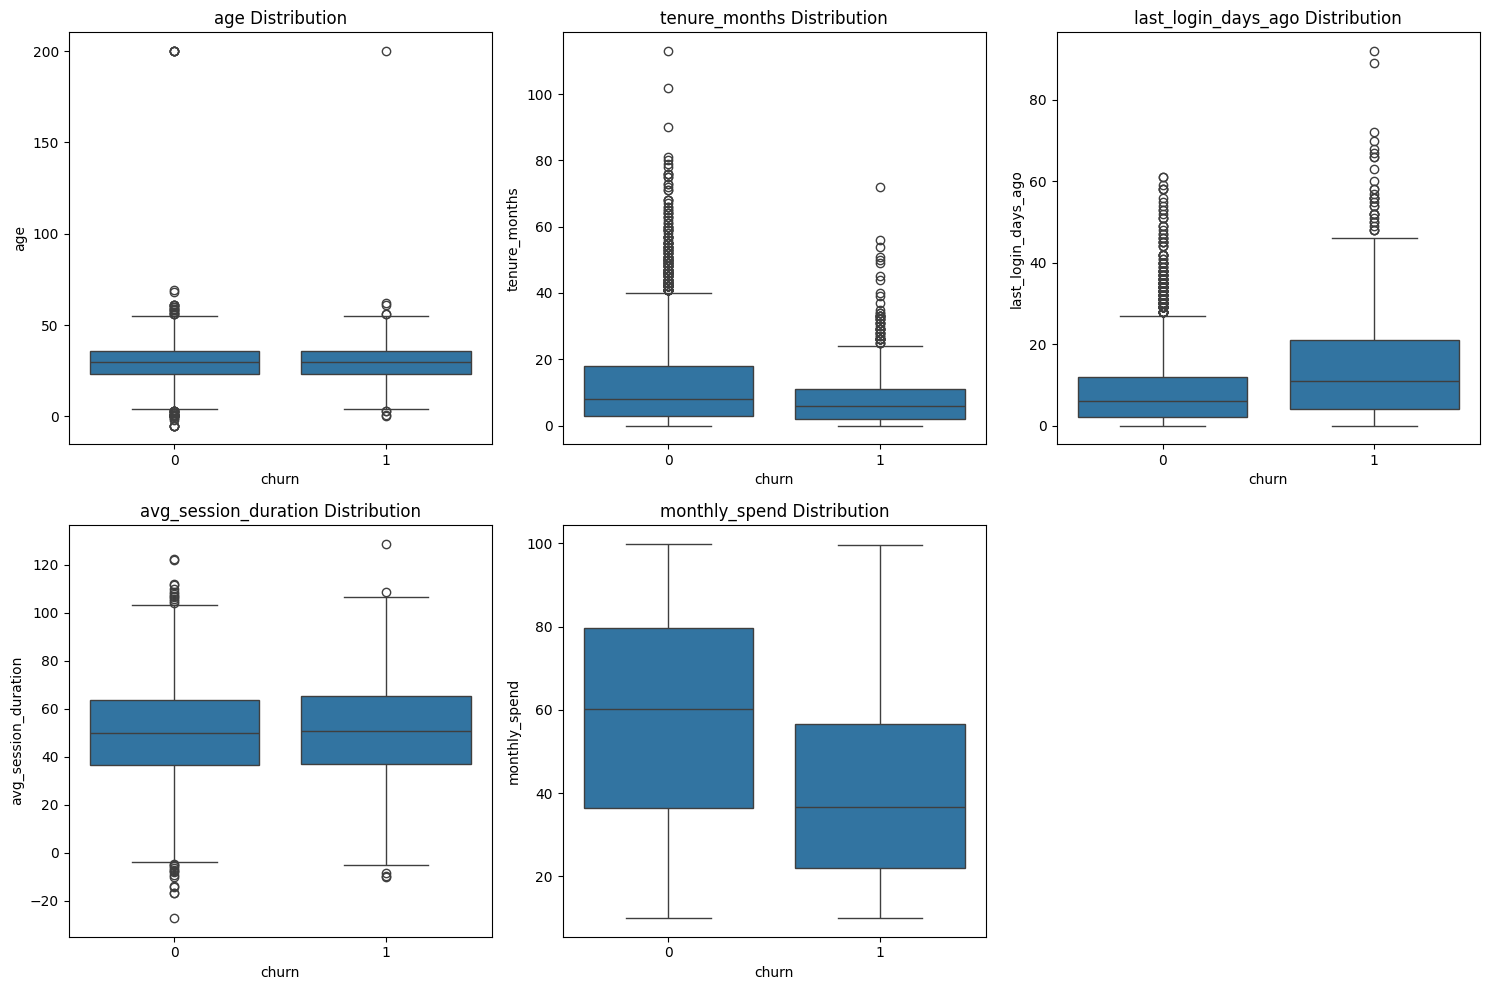

In [17]:
# 1. 自动筛选数值型特征 (Feature Selection)
# 排除掉不需要画图的列 (比如 churn 是标签，user_id 是废话)
cols_to_plot = df.select_dtypes(include=['number']).columns.tolist()
if 'churn' in cols_to_plot: cols_to_plot.remove('churn') 

# 2. 批量画图 (Subplot Magic)
n_cols = 3  # 每行画 3 张图
n_rows = (len(cols_to_plot) - 1) // n_cols + 1 # 自动算需要几行

plt.figure(figsize=(15, 5 * n_rows)) # 自动调整画布高度

for i, col in enumerate(cols_to_plot):
    plt.subplot(n_rows, n_cols, i+1)
    # 🌟 关键：x='churn'。看不同人群在这个变量上有没有明显差异！
    sns.boxplot(data=df, x='churn', y=col) 
    plt.title(f'{col} Distribution')

plt.tight_layout() # 自动排列，不重叠

In [ ]:
# 处理age异常值
df = df[df['age'].isin(range(0,100))]


Text(0.5, 1.0, 'Feature Correlation Heatmap')

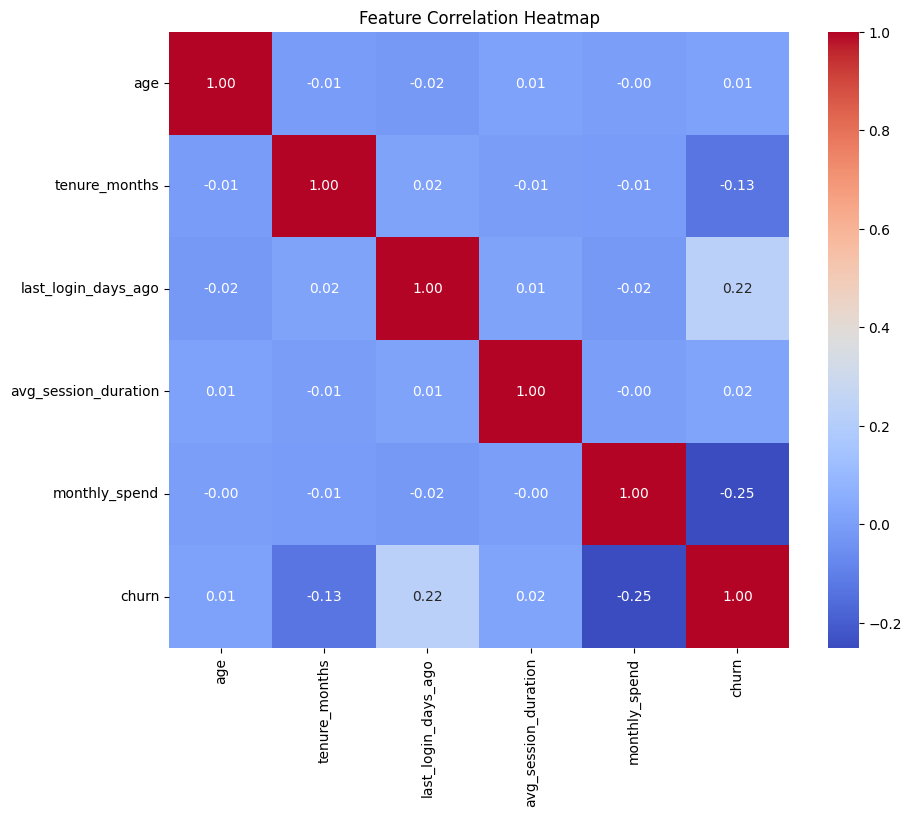

In [22]:
# 1. 算出相关系数矩阵 (关键参数: numeric_only=True，自动过滤掉文字列)
corr_matrix = df.corr(numeric_only=True)

# 2. 画热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')

## 3. 特征工程 (Feature Engineering)
机器不认识字符串，也不懂量纲。我们需要把数据转换成模型能吃的格式。

**任务**：
1.  **处理分类变量 (Categorical)**: 对 `gender` 和 `subscription_type` 进行 One-Hot Encoding (`pd.get_dummies`)。
2.  **处理数值变量 (Numerical)**: (可选) 对 `age`, `monthly_spend` 等进行标准化 (StandardScaler) 或 归一化。
3.  **构造新特征 (Feature Creation)**: 比如 `avg_spend_per_session` = `monthly_spend` / 30 / (`avg_session_duration`/60)？ (发挥你的想象力)

<Axes: >

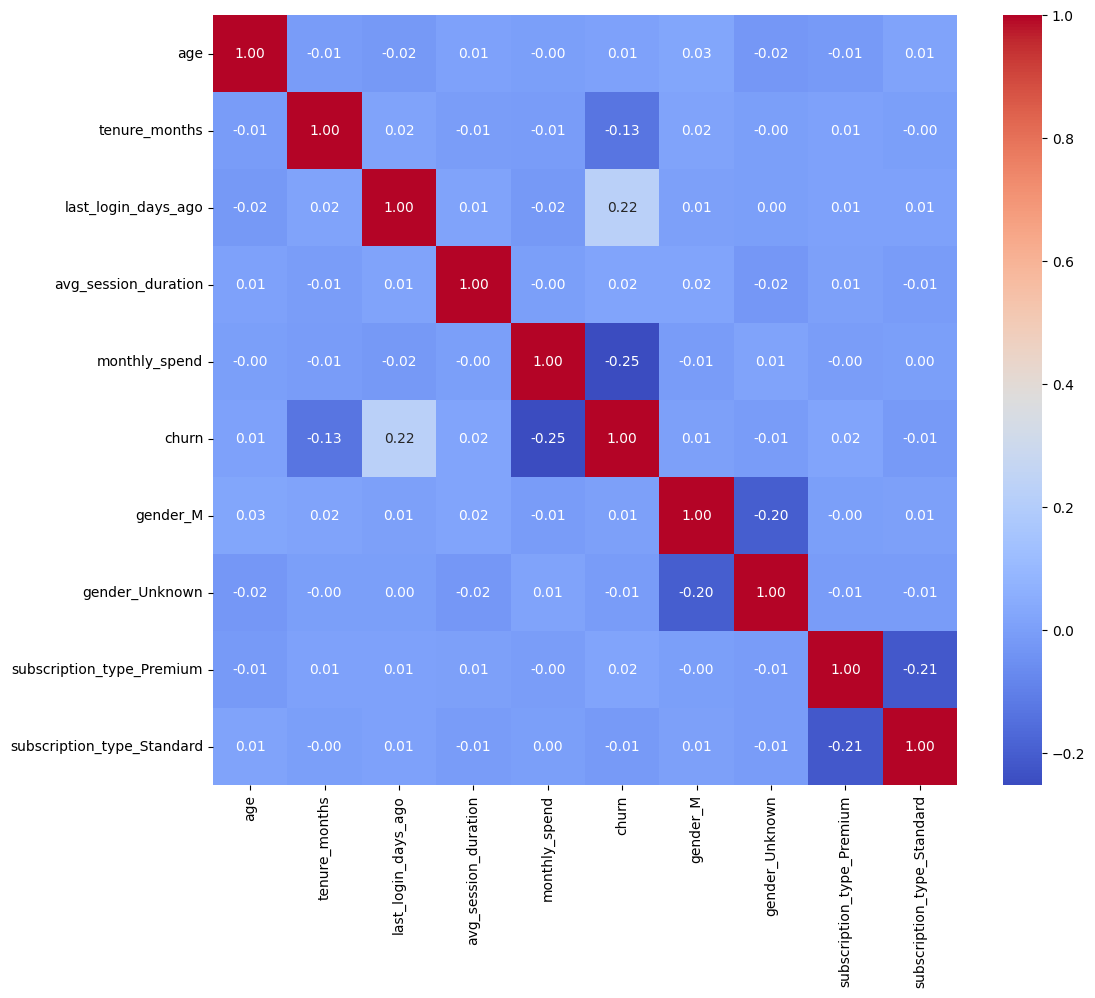

In [ ]:
# 🛠️ 你的代码：特征处理
# drop_first=True 是为了避免多重共线性 (比如有 Male/Female，只需要保留 Male 列，为0就是Female)
df_processed = pd.get_dummies(df, columns=['gender', 'subscription_type'], drop_first=True)
df_processed
# 再次看看相关性 (这次能看到 VIP 的影响了！)
plt.figure(figsize=(12, 10))
sns.heatmap(df_processed.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

In [26]:
from sklearn.preprocessing import StandardScaler

# 1. 构造新特征 (发挥你的业务直觉！)
# 计算“每分钟花了多少钱” -> 找出真正的土豪
# 注意：分母加 0.1 是为了防止除以 0 报错
df_processed['dollars_per_minute'] = df_processed['monthly_spend'] / (df_processed['avg_session_duration'] + 0.1)

# 2. 标准化 (把所有数字拉回 0~1 的尺度)
scaler = StandardScaler()

# 这一步我们只缩放“数值型”的列，不缩放 0/1 的列
cols_to_scale = ['age', 'tenure_months', 'last_login_days_ago', 'avg_session_duration', 'monthly_spend', 'dollars_per_minute']

# 这里的语法有点怪，但记下来就好：只改变选中的列
df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])

# 3. 看看结果
print("特征工程完成！现在的 Mean 应该是 0 左右:")
df_processed[cols_to_scale].describe().round(2)

特征工程完成！现在的 Mean 应该是 0 左右:


,age,tenure_months,last_login_days_ago,avg_session_duration,monthly_spend,dollars_per_minute
count,4899.00,4899.00,4899.00,4899.00,4899.00,4899.00
mean,-0.00,0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.98,-0.94,-0.96,-3.85,-1.74,-37.26
25%,-0.58,-0.70,-0.67,-0.67,-0.87,-0.08
50%,0.02,-0.29,-0.28,0.00,0.01,-0.02
75%,0.54,0.43,0.31,0.68,0.86,0.05
max,14.60,8.20,8.02,3.92,1.74,28.67


## 4. 模型训练 (Model Training)
我们将数据拆分为训练集 (Train) 和测试集 (Test)。
**注意**：为了模拟真实业务，不要发生 "数据穿越" (Data Leakage)。`user_id` 这种显然不能进模型。

**任务**：
1.  使用 `train_test_split` 拆分数据 (80% Train, 20% Test)。
2.  训练一个逻辑回归 (`LogisticRegression`) 作为 Baseline。
3.  (进阶) 训练一个 `RandomForestClassifier` 或 `XGBoost`。

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


# 1. 准备 X (特征) 和 y (答案)
# 记得 drop 掉 'churn' (它是答案) 和 'user_id' (它是废话，对预测没用)
X = df_processed.drop(columns=['churn', 'user_id']) 
y = df_processed['churn']

# 2. 切分数据 (80% 训练，20% 考试)
# random_state=42 保证每次切分结果一样，方便复现 (42是宇宙终极答案 🌌)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("训练集形状 (老师教的):", X_train.shape)
print("测试集形状 (期末考试):", X_test.shape)


训练集形状 (老师教的): (3919, 10)
测试集形状 (期末考试): (980, 10)


In [28]:
model = LogisticRegression()
model.fit(X_train,y_train)

./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
./Library/Python/3.9/lib/python/site-

LogisticRegression()

In [30]:
# 4. 预测与评估 (Predict & Evaluate)
# 让它做考卷 (X_test)，也就是预测未来的用户会不会走
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"模型准确率: {accuracy:.2%}")

# ---------------------------------------------------------
# 5. 混淆矩阵 (Confusion Matrix) - 为什么只看准确率是不够的？
# ---------------------------------------------------------
# 准确率 (Accuracy) 只是一个总分 (e.g., 99分)。
# 混淆矩阵 (Confusion Matrix) 是 "试卷分析"：
# - 你到底是做错了选择题，还是做错了大题？
# - 你是把 "要走的人" 错判成了 "留下来" (放过坏人)？
# - 还是把 "留下来的人" 错判成了 "要走" (冤枉好人)？

cm = confusion_matrix(y_test, y_pred)
print("\n--- 混淆矩阵 (Confusion Matrix) ---")
print(cm)
print("-----------------------------------")
print("[[TN, FP],")
print(" [FN, TP]]")
# TN: 真没走 (预测没走，实际没走) - 答对了
# TP: 真走了 (预测走了，实际走了) - 答对了
# FP: 虚惊一场 (预测走了，实际没走) - 误报 (Type I Error)
# FN: 漏网之鱼 (预测没走，实际走了) - 漏报 (Type II Error) -> 这种最可怕！因为我们没挽留他。

模型准确率: 82.86%

--- 混淆矩阵 (Confusion Matrix) ---
[[793  14]
 [154  19]]
-----------------------------------
[[TN, FP],
 [FN, TP]]


./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [31]:
# 换个更猛的算法：随机森林
# n_estimators=100 表示请 100 棵树来投票
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 再次考试
y_pred_rf = rf_model.predict(X_test)

print(f"随机森林准确率: {accuracy_score(y_test, y_pred_rf):.2%}")
print("\n--- 随机森林混淆矩阵 ---")
print(confusion_matrix(y_test, y_pred_rf))

# 看看这次能不能多抓几个？

随机森林准确率: 81.94%

--- 随机森林混淆矩阵 ---
[[783  24]
 [153  20]]


## 5. 模型评估与解释 (Evaluation & Interpretation)
老板不关心 Accuracy (因为只要全猜不流失，Accuracy 也能很高)。老板关心的是：**我们抓住了多少流失用户？误抓了多少？**

**任务**：
1.  看 **Classifiction Report** (Focus on Recall & Precision for Class 1)。
2.  计算 **AUC** 值。
3.  **最重要的部分**：使用 Feature Importance (树模型自带) 或 SHAP 值，解释 **哪些特征最能预测流失**？

In [ ]:
# 🚀 必杀技：使用 Balanced Random Forest 解决类别不平衡
# 这会让模型对“流失用户”格外敏感
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_balanced.fit(X_train, y_train)

y_pred_balanced = rf_balanced.predict(X_test)

print(f"加权随机森林准确率: {accuracy_score(y_test, y_pred_balanced):.2%}")
print("\n--- 加权混淆矩阵 (让老板看看这次抓了多少？) ---")
print(confusion_matrix(y_test, y_pred_balanced))


# 🧐 查看 Feature Importance (特征重要性) - 解释为什么会流失？
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 提取特征重要性
importances = rf_balanced.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.show()

print(feature_imp_df.head(5))


## 6. 业务策略产出 (Business Action)

**核心洞察**：
1.  **"每分钟氪金强度" (Dollars per Minute) 是关键预测指标**：
    - 高氪金但在线时间短的用户（"快餐型土豪"）可能是高风险群体。
    - **策略**：为这部分用户推送"省时礼包"或"扫荡券"，承认并满足他们"用金钱换时间"的需求，而不是强行通过活动拉长他们的在线时间。

2.  **月消费 (Monthly Spend) 依然是第一指标**：
    - 消费越高，流失代价越大。
    - **策略**：建立 VIP 专属导购/推荐通道。只要预测出高消费用户的流失概率超过 50%（不需要等到 100%），立即人工介入关怀。

3.  **最近登录时间 (Last Login Days Ago)**：
    - 这是最直接的预警信号。
    - **策略**：设置自动化规则。一旦用户超过 7 天未登录（Top 10% 风险阈值），自动触发 Push 通知 + 回归礼包。

**至此，你的机器学习马拉松 (Case 4) 圆满结束！** 🏁
你不仅跑通了全流程，还亲手证明了 Feature Engineering 的价值。
